### Indlæsning af data og biblioteker

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

# if libaries are not installed, run the following command in terminal:
# pip install pandas numpy seaborn matplotlib statsmodels

In [59]:
odr = pd.read_csv("data/age-dependency-ratio-old.csv")
internet = pd.read_csv("data/share-of-individuals-using-the-internet.csv")
tfp = pd.read_csv("data/total-factor-productivity.csv") 
patens = pd.read_csv("data/patent-applications-per-million.csv")
hc = pd.read_csv("data/HC.csv")

In [60]:
# Gør HC fra wide til long format
hc_long = hc.melt(
    id_vars=["ISO code", "Country", "Variable code", "Variable name"],
    var_name="year",
    value_name="hc"
)

# Omdøb kolonner så de matcher dine andre datasæt
hc_long = hc_long.rename(columns={
    "ISO code": "code",
    "Country": "country"
})

# Gør year numerisk
hc_long["year"] = pd.to_numeric(hc_long["year"], errors="coerce")

# Fjern rækker uden år eller HC-værdi
hc_long = hc_long.dropna(subset=["year", "hc"])

# Behold kun de nødvendige kolonner
hc_long = hc_long[["code", "year", "hc"]]

In [61]:
odr = odr.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Age dependency ratio, old (% of working-age population)": "odr"
})

internet = internet.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Share of the population using the Internet": "internet_use"
})

tfp = tfp.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Total factor productivity level": "tfp"
})

patens = patens.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Patent applications per million people": "patens"
})

### Begrænser perioden og merger datasættene

In [62]:
#Begræns perioden for alle datasæt
start = 2001
end = 2020

# Gør year numerisk
for df in [odr, tfp, internet, patens, hc_long]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

#Udfører begrænsning
odr = odr[(odr["year"] >= start) & (odr["year"] <= end)]
tfp = tfp[(tfp["year"] >= start) & (tfp["year"] <= end)]
internet = internet[(internet["year"] >= start) & (internet["year"] <= end)]
patens = patens[(patens["year"] >= start) & (patens["year"] <= end)]
hc_long = hc_long[(hc_long["year"] >= start) & (hc_long["year"] <= end)]

In [63]:
panel = internet[["country", "code", "year", "internet_use"]].merge(
    odr[["code", "year", "odr"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    tfp[["code", "year", "tfp"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    patens[["code", "year", "patens"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    hc_long[["code", "year", "hc"]],
    on=["code", "year"],
    how="inner"
)

#panel.head(30)

In [64]:
expected_years = end - start + 1

# behold kun lande der har alle år
balanced_codes = (
    panel.groupby("code")["year"]
    .nunique()
    .loc[lambda x: x == expected_years]
    .index
)

panel_balanced = panel[panel["code"].isin(balanced_codes)].copy()

# sortér pænt
panel_balanced = panel_balanced.sort_values(["code", "year"]).reset_index(drop=True)

print("Antal lande:", panel_balanced["code"].nunique())
print("Antal år pr. land:")
print(panel_balanced.groupby("code")["year"].nunique().value_counts())


Antal lande: 56
Antal år pr. land:
year
20    56
Name: count, dtype: int64


### Opretter nye dataframes med aggrerede data

2-, 4- og 5-års intervaller

In [65]:
panel_2yr = panel_balanced.copy()

# Lav 2-års perioder
panel_2yr["period_start"] = start + 2 * ((panel_2yr["year"] - start) // 2)
panel_2yr["period_end"] = panel_2yr["period_start"] + 1

# Variabler der skal gennemsnittes
vars_to_average = [
    "tfp",
    "odr",
    "hc", 
    "internet_use",
    "patens",
    "schooling"
]

# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 2-års periode
panel_2yr = (
    panel_2yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_2yr["year"] = panel_2yr["period_start"]
panel_2yr["log_internet_use"] = np.log(panel_2yr["internet_use"])
panel_2yr["log_tfp"] = np.log(panel_2yr["tfp"])
panel_2yr["log_patens"] = np.log(panel_2yr["patens"])

In [66]:
panel_4yr = panel_balanced.copy()

# Lav 4-års perioder
panel_4yr["period_start"] = start + 4 * ((panel_4yr["year"] - start) // 4)
panel_4yr["period_end"] = panel_4yr["period_start"] + 3
# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 4-års periode
panel_4yr = (
    panel_4yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_4yr["year"] = panel_4yr["period_start"]
panel_4yr["log_internet_use"] = np.log(panel_4yr["internet_use"])
panel_4yr["log_tfp"] = np.log(panel_4yr["tfp"])
panel_4yr["log_patens"] = np.log(panel_4yr["patens"])

In [67]:
panel_5yr = panel_balanced.copy()

# Lav 5-års perioder
panel_5yr["period_start"] = start + 5 * ((panel_5yr["year"] - start) // 5)
panel_5yr["period_end"] = panel_5yr["period_start"] + 4
# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 5-års periode
panel_5yr = (
    panel_5yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_5yr["year"] = panel_5yr["period_start"]
panel_5yr["log_internet_use"] = np.log(panel_5yr["internet_use"])
panel_5yr["log_tfp"] = np.log(panel_5yr["tfp"])
panel_5yr["log_patens"] = np.log(panel_5yr["patens"])

In [68]:
panel_balanced["log_internet_use"] = np.log(panel_balanced["internet_use"])
panel_balanced["log_tfp"] = np.log(panel_balanced["tfp"])
panel_balanced["log_patens"] = np.log(panel_balanced["patens"])

## Deskriptiv analyse

In [71]:
# describe the data
print(panel_balanced[["odr", "tfp", "internet_use", "patens", "hc"]].describe())

               odr          tfp  internet_use       patens           hc
count  1120.000000  1120.000000   1120.000000  1120.000000  1120.000000
mean     19.107069     0.980112     55.729048   204.846541     3.019955
std       8.512082     0.103011     28.438004   488.362940     0.473902
min       3.261457     0.447377      0.233130     0.088197     1.615594
25%      10.892557     0.936280     32.399550    16.495499     2.676763
50%      19.972482     0.986844     61.965950    56.144457     3.099336
75%      25.808732     1.032849     80.300000   198.208843     3.369088
max      48.979670     1.309535     99.532800  3481.676300     3.854527


# Modeller

##### $\log(\text{TFP}_{it}) = \beta_0 + \beta_1 ODR_{it} + \beta_2 Patenter_{it} + \beta_3 HC_{it} + \beta_4 \log(\text{Internetbrug}_{it}) + \alpha_i + \lambda_t + u_{it}$

In [13]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + patens + C(code) + C(year)",
    data=df_est
)
    
results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)


# estimation
model3 = smf.ols(
    "log_tfp ~ odr + hc + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)


# estimation
model4 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)


results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['ODR', 'Internet Use', 'Patens', 'HC'],
    regressor_order=['odr', 'patens', 'hc', 'log_internet_use'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + log(internet_use) + patens + hc + FE(code) + FE(year)")
print(results)



log(tfp) ~ odr + log(internet_use) + patens + hc + FE(code) + FE(year)

                   ODR    Internet Use  Patens      HC   
---------------------------------------------------------
odr              0.0018   0.0035       0.0028   0.0110** 
                 (0.0039) (0.0041)     (0.0043) (0.0045) 
patens                    0.0001       0.0001*  0.0001** 
                          (0.0001)     (0.0001) (0.0001) 
hc                                     -0.1264  -0.1861**
                                       (0.0900) (0.0908) 
log_internet_use                                0.0738***
                                                (0.0226) 
R-squared        0.6923   0.7052       0.7093   0.7482   
R-squared Adj.   0.6701   0.6837       0.6879   0.7293   
N                1120     1120         1120     1120     
R2               0.692    0.705        0.709    0.748    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Aggregerede modeller

### Results - Aggregerede fulde model

In [ ]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)


# kopi af det færdige balanced panel
df_est = panel_2yr.copy() 

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)
    
results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_4yr.copy() 

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)


# kopi af det færdige balanced panel
df_est = panel_5yr.copy() 

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + hc + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'log_internet_use', 'patens', 'hc'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
    }
)

#print the model
print("log(tfp) ~ odr + log(internet_use) + patens + hc + FE(code) + FE(year)")
print(results)



log(tfp) ~ odr + log(internet_use) + patens + hc + FE(code) + FE(year)

                   1 year   2 years   4 years   5 years 
--------------------------------------------------------
odr              0.0110**  0.0112**  0.0111**  0.0112** 
                 (0.0045)  (0.0048)  (0.0052)  (0.0056) 
log_internet_use 0.0738*** 0.0751*** 0.0754*** 0.0765***
                 (0.0226)  (0.0243)  (0.0266)  (0.0280) 
patens           0.0001**  0.0001**  0.0002**  0.0002** 
                 (0.0001)  (0.0001)  (0.0001)  (0.0001) 
hc               -0.1861** -0.1860** -0.1843*  -0.1902* 
                 (0.0908)  (0.0943)  (0.1026)  (0.1084) 
R-squared        0.7482    0.7537    0.7670    0.7745   
R-squared Adj.   0.7293    0.7196    0.6990    0.6877   
N                1120      560       280       224      
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


### Results - Aggregerede model uden internet

In [15]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr  + hc + patens + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + hc + patens + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + hc + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + hc + patens + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)


In [16]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'hc', 'patens'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
    }
)

#print the model
print("log(tfp) ~ odr + hc + patens + FE(code) + FE(year)")
print(results)

log(tfp) ~ odr + hc + patens + FE(code) + FE(year)

                1 year  2 years  4 years  5 years 
--------------------------------------------------
odr            0.0028   0.0028   0.0026   0.0026  
               (0.0043) (0.0045) (0.0049) (0.0052)
hc             -0.1264  -0.1259  -0.1239  -0.1273 
               (0.0900) (0.0934) (0.1015) (0.1088)
patens         0.0001*  0.0001   0.0001   0.0002  
               (0.0001) (0.0001) (0.0001) (0.0001)
R-squared      0.7093   0.7156   0.7323   0.7407  
R-squared Adj. 0.6879   0.6769   0.6558   0.6431  
N              1120     560      280      224     
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Deskriptiv statistik

In [17]:
#lav deskriptiv statistik over paneldata
descriptive_stats = panel_balanced[["odr", "tfp", "internet_use", "patens", "hc"]].describe()
print(descriptive_stats.round(4))


             odr        tfp  internet_use     patens         hc
count  1120.0000  1120.0000     1120.0000  1120.0000  1120.0000
mean     19.1071     0.9801       55.7290   204.8465     3.0200
std       8.5121     0.1030       28.4380   488.3629     0.4739
min       3.2615     0.4474        0.2331     0.0882     1.6156
25%      10.8926     0.9363       32.3996    16.4955     2.6768
50%      19.9725     0.9868       61.9660    56.1445     3.0993
75%      25.8087     1.0328       80.3000   198.2088     3.3691
max      48.9797     1.3095       99.5328  3481.6763     3.8545


In [18]:
region_map = {
    # Europa
    "Austria": "Europa",
    "Belgium": "Europa",
    "Bulgaria": "Europa",
    "Croatia": "Europa",
    "Czechia": "Europa",
    "Denmark": "Europa",
    "Estonia": "Europa",
    "Finland": "Europa",
    "France": "Europa",
    "Germany": "Europa",
    "Greece": "Europa",
    "Hungary": "Europa",
    "Iceland": "Europa",
    "Latvia": "Europa",
    "Lithuania": "Europa",
    "Luxembourg": "Europa",
    "Moldova": "Europa",
    "Netherlands": "Europa",
    "Norway": "Europa",
    "Poland": "Europa",
    "Portugal": "Europa",
    "Romania": "Europa",
    "Russia": "Europa",
    "Slovakia": "Europa",
    "Spain": "Europa",
    "Sweden": "Europa",
    "Switzerland": "Europa",
    "Ukraine": "Europa",
    "United Kingdom": "Europa",

    # Asien
    "China": "Asien",
    "Hong Kong": "Asien",
    "India": "Asien",
    "Israel": "Asien",
    "Japan": "Asien",
    "Jordan": "Asien",
    "Malaysia": "Asien",
    "Philippines": "Asien",
    "Singapore": "Asien",
    "South Korea": "Asien",
    "Thailand": "Asien",
    "Turkey": "Asien",

    # Afrika
    "South Africa": "Afrika",
    "Zambia": "Afrika",

    # Amerika
    "Argentina": "Amerika",
    "Brazil": "Amerika",
    "Canada": "Amerika",
    "Chile": "Amerika",
    "Colombia": "Amerika",
    "Costa Rica": "Amerika",
    "Dominican Republic": "Amerika",
    "Guatemala": "Amerika",
    "Jamaica": "Amerika",
    "Mexico": "Amerika",
    "Peru": "Amerika",
    "United States": "Amerika",

    # Oceanien
    "New Zealand": "Oceanien"
}

panel_balanced["regions"] = panel_balanced["country"].map(region_map)

In [19]:
#print et diagram med region_map fordeling i datasættet
region_counts = (
    panel_balanced
    .groupby("regions")["code"]
    .nunique()
)   
labels = region_counts.index
sizes = region_counts.values

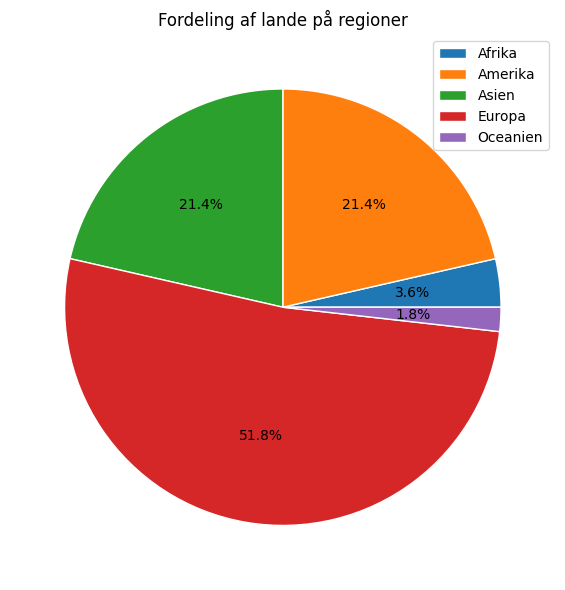

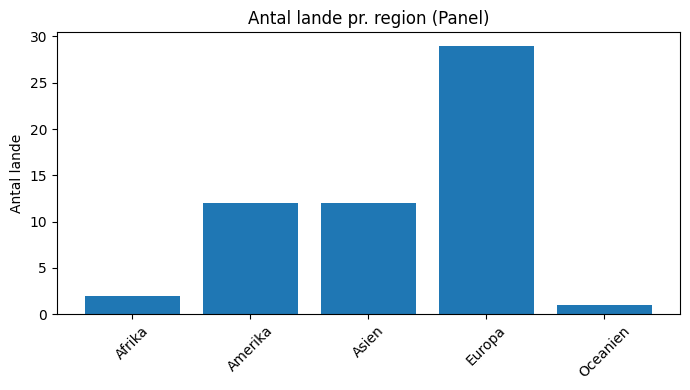

In [20]:

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    autopct='%1.1f%%',
    wedgeprops={'edgecolor': 'white'}
)
plt.legend(labels, loc="best")
plt.title("Fordeling af lande på regioner")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.bar(labels, sizes)
plt.title("Antal lande pr. region (Panel)")
plt.ylabel("Antal lande")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
tfp.describe()

,year,tfp
count,2390.000000,2390.000000
mean,2010.471130,1.034532
std,5.761461,0.270962
min,2001.000000,0.244468
25%,2005.000000,0.934052
50%,2010.000000,0.998378
75%,2015.000000,1.068062
max,2020.000000,3.400313


### Udviklingen i odr over tiden

In [22]:
#Udviklingen af ODR over tid for alle perioder i datasættet
odr = pd.read_csv("data/age-dependency-ratio-old.csv")

In [23]:
odr = odr[odr["Code"].notna()]  # beholder kun rigtige lande (3-letter codes)

In [24]:
odr_avg = (
    odr
    .groupby("Year")["Age dependency ratio, old (% of working-age population)"]
    .mean()
    .reset_index()
)

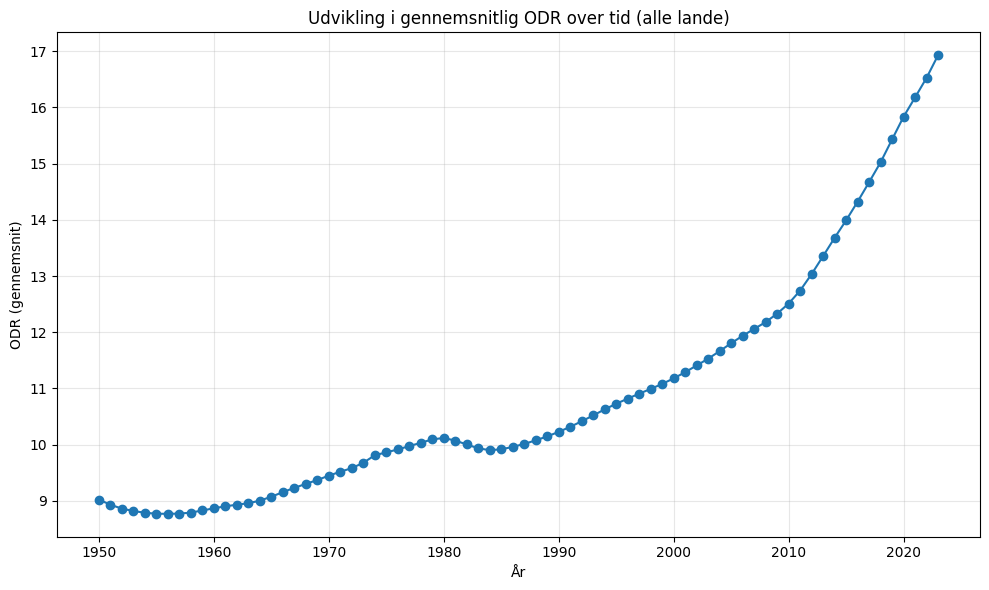

In [25]:
plt.figure(figsize=(10,6))

plt.plot(odr_avg["Year"], odr_avg["Age dependency ratio, old (% of working-age population)"], marker='o')

plt.title("Udvikling i gennemsnitlig ODR over tid (alle lande)")
plt.xlabel("År")
plt.ylabel("ODR (gennemsnit)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()